In [1]:
from pathlib import Path

import pandas as pd

correlation_dir = Path("correlation_matrices_all_subjects")
correlation_matrices = {}

for csv_path in sorted(correlation_dir.glob("*_correlation_matrix_avg.csv")):
    subject_id = csv_path.stem.replace("_correlation_matrix_avg", "")
    correlation_matrices[subject_id] = pd.read_csv(csv_path, index_col=0)

print(f"Loaded {len(correlation_matrices)} correlation matrices from {correlation_dir}")
if correlation_matrices:
    first_subject = next(iter(correlation_matrices))
    print(f"Example: {first_subject} -> {correlation_matrices[first_subject].shape}")

Loaded 125 correlation matrices from correlation_matrices_all_subjects
Example: sub-NORB00001_ses-1 -> (19, 19)


In [2]:
import networkx as nx
import numpy as np
import pandas as pd

edge_betweenness_rows = []

for subject_session, correlation_matrix in correlation_matrices.items():
    matrix = correlation_matrix.astype(float).copy()

    # Convert correlations into positive edge lengths for shortest-path betweenness.
    edge_length_matrix = 1.0 / matrix.abs()
    np.fill_diagonal(edge_length_matrix.values, 0.0)

    graph = nx.from_pandas_adjacency(edge_length_matrix)
    edge_betweenness = nx.edge_betweenness_centrality(graph, weight="weight", normalized=True)

    for u, v in graph.edges():
        edge_key = tuple(sorted((u, v)))
        edge_betweenness_rows.append(
            {
                "subject_session": subject_session,
                "edge_u": edge_key[0],
                "edge_v": edge_key[1],
                "edge_betweenness": float(edge_betweenness.get((u, v), edge_betweenness.get((v, u), 0.0))),
            }
        )

edge_betweenness_df = pd.DataFrame(edge_betweenness_rows)
edge_betweenness_summary = (
    edge_betweenness_df.groupby(["edge_u", "edge_v"], as_index=False)["edge_betweenness"]
    .agg(mean="mean", std="std", min="min", max="max")
)

print(f"Computed edge betweenness for {edge_betweenness_df['subject_session'].nunique()} subject-session pairs")
print(f"Total edge observations: {len(edge_betweenness_df)}")
print("Per-subject-session edge betweenness preview:")
display(edge_betweenness_df.head())
print("Aggregated edge betweenness across subject-session pairs:")
display(edge_betweenness_summary.head())

Computed edge betweenness for 125 subject-session pairs
Total edge observations: 21375
Per-subject-session edge betweenness preview:


,subject_session,edge_u,edge_v,edge_betweenness
0,sub-NORB00001_ses-1,Fp1,Fp2,0.005848
1,sub-NORB00001_ses-1,F3,Fp1,0.005848
2,sub-NORB00001_ses-1,F4,Fp1,0.005848
3,sub-NORB00001_ses-1,C3,Fp1,0.005848
4,sub-NORB00001_ses-1,C4,Fp1,0.005848


Aggregated edge betweenness across subject-session pairs:


,edge_u,edge_v,mean,std,min,max
0,C3,C4,0.009965,0.006928,0.005848,0.052632
1,C3,CZ,0.008889,0.008584,0.005848,0.070175
2,C3,F3,0.012351,0.008700,0.000000,0.052632
3,C3,F4,0.010994,0.006750,0.000000,0.040936
4,C3,F7,0.014924,0.011396,0.000000,0.046784


In [3]:
from itertools import combinations

# Build a fixed edge order so every subject-session pair produces exactly one value per edge.
all_edges = sorted({(row.edge_u, row.edge_v) for row in edge_betweenness_df.itertuples(index=False)})
edge_betweenness_wide = (
    edge_betweenness_df.assign(edge=list(zip(edge_betweenness_df["edge_u"], edge_betweenness_df["edge_v"])))
    .pivot_table(
        index="subject_session",
        columns="edge",
        values="edge_betweenness",
        aggfunc="mean",
        fill_value=0.0,
    )
    .reindex(columns=all_edges, fill_value=0.0)
)

pairwise_jaccard_rows = []
pairwise_jaccard_summary_rows = []

for subject_session_a, subject_session_b in combinations(edge_betweenness_wide.index, 2):
    vector_a = edge_betweenness_wide.loc[subject_session_a].to_numpy(dtype=float)
    vector_b = edge_betweenness_wide.loc[subject_session_b].to_numpy(dtype=float)

    numerator = np.minimum(vector_a, vector_b)
    denominator = np.maximum(vector_a, vector_b)

    per_edge_jaccard = np.zeros_like(numerator)
    both_zero = denominator == 0
    per_edge_jaccard[both_zero] = 1.0
    valid = ~both_zero
    per_edge_jaccard[valid] = numerator[valid] / denominator[valid]

    pairwise_jaccard_summary_rows.append(
        {
            "subject_session_a": subject_session_a,
            "subject_session_b": subject_session_b,
            "weighted_jaccard_index": float(numerator.sum() / denominator.sum()) if denominator.sum() else 1.0,
            "n_edges": len(all_edges),
        }
    )

    for (edge_u, edge_v), jaccard_value in zip(all_edges, per_edge_jaccard):
        pairwise_jaccard_rows.append(
            {
                "subject_session_a": subject_session_a,
                "subject_session_b": subject_session_b,
                "edge_u": edge_u,
                "edge_v": edge_v,
                "jaccard_index": float(jaccard_value),
            }
        )

pairwise_jaccard_df = pd.DataFrame(pairwise_jaccard_rows)
pairwise_jaccard_summary_df = pd.DataFrame(pairwise_jaccard_summary_rows)

print(f"Computed per-edge Jaccard values for {len(pairwise_jaccard_summary_df)} subject-session pairs")
print(f"Each pair has {len(all_edges)} edge-level Jaccard values")
print("Per-edge Jaccard preview:")
display(pairwise_jaccard_df.head())
print("Pairwise weighted Jaccard summary preview:")
display(pairwise_jaccard_summary_df.head())

Computed per-edge Jaccard values for 7750 subject-session pairs
Each pair has 171 edge-level Jaccard values
Per-edge Jaccard preview:


,subject_session_a,subject_session_b,edge_u,edge_v,jaccard_index
0,sub-NORB00001_ses-1,sub-NORB00003_ses-1,C3,C4,1.0
1,sub-NORB00001_ses-1,sub-NORB00003_ses-1,C3,CZ,0.5
2,sub-NORB00001_ses-1,sub-NORB00003_ses-1,C3,F3,1.0
3,sub-NORB00001_ses-1,sub-NORB00003_ses-1,C3,F4,1.0
4,sub-NORB00001_ses-1,sub-NORB00003_ses-1,C3,F7,0.5


Pairwise weighted Jaccard summary preview:


,subject_session_a,subject_session_b,weighted_jaccard_index,n_edges
0,sub-NORB00001_ses-1,sub-NORB00003_ses-1,0.458194,171
1,sub-NORB00001_ses-1,sub-NORB00005_ses-1,0.532646,171
2,sub-NORB00001_ses-1,sub-NORB00006_ses-1,0.621622,171
3,sub-NORB00001_ses-1,sub-NORB00007_ses-1,0.398026,171
4,sub-NORB00001_ses-1,sub-NORB00008_ses-1,0.398058,171


Selected subject-session pairs used in heatmap: 231


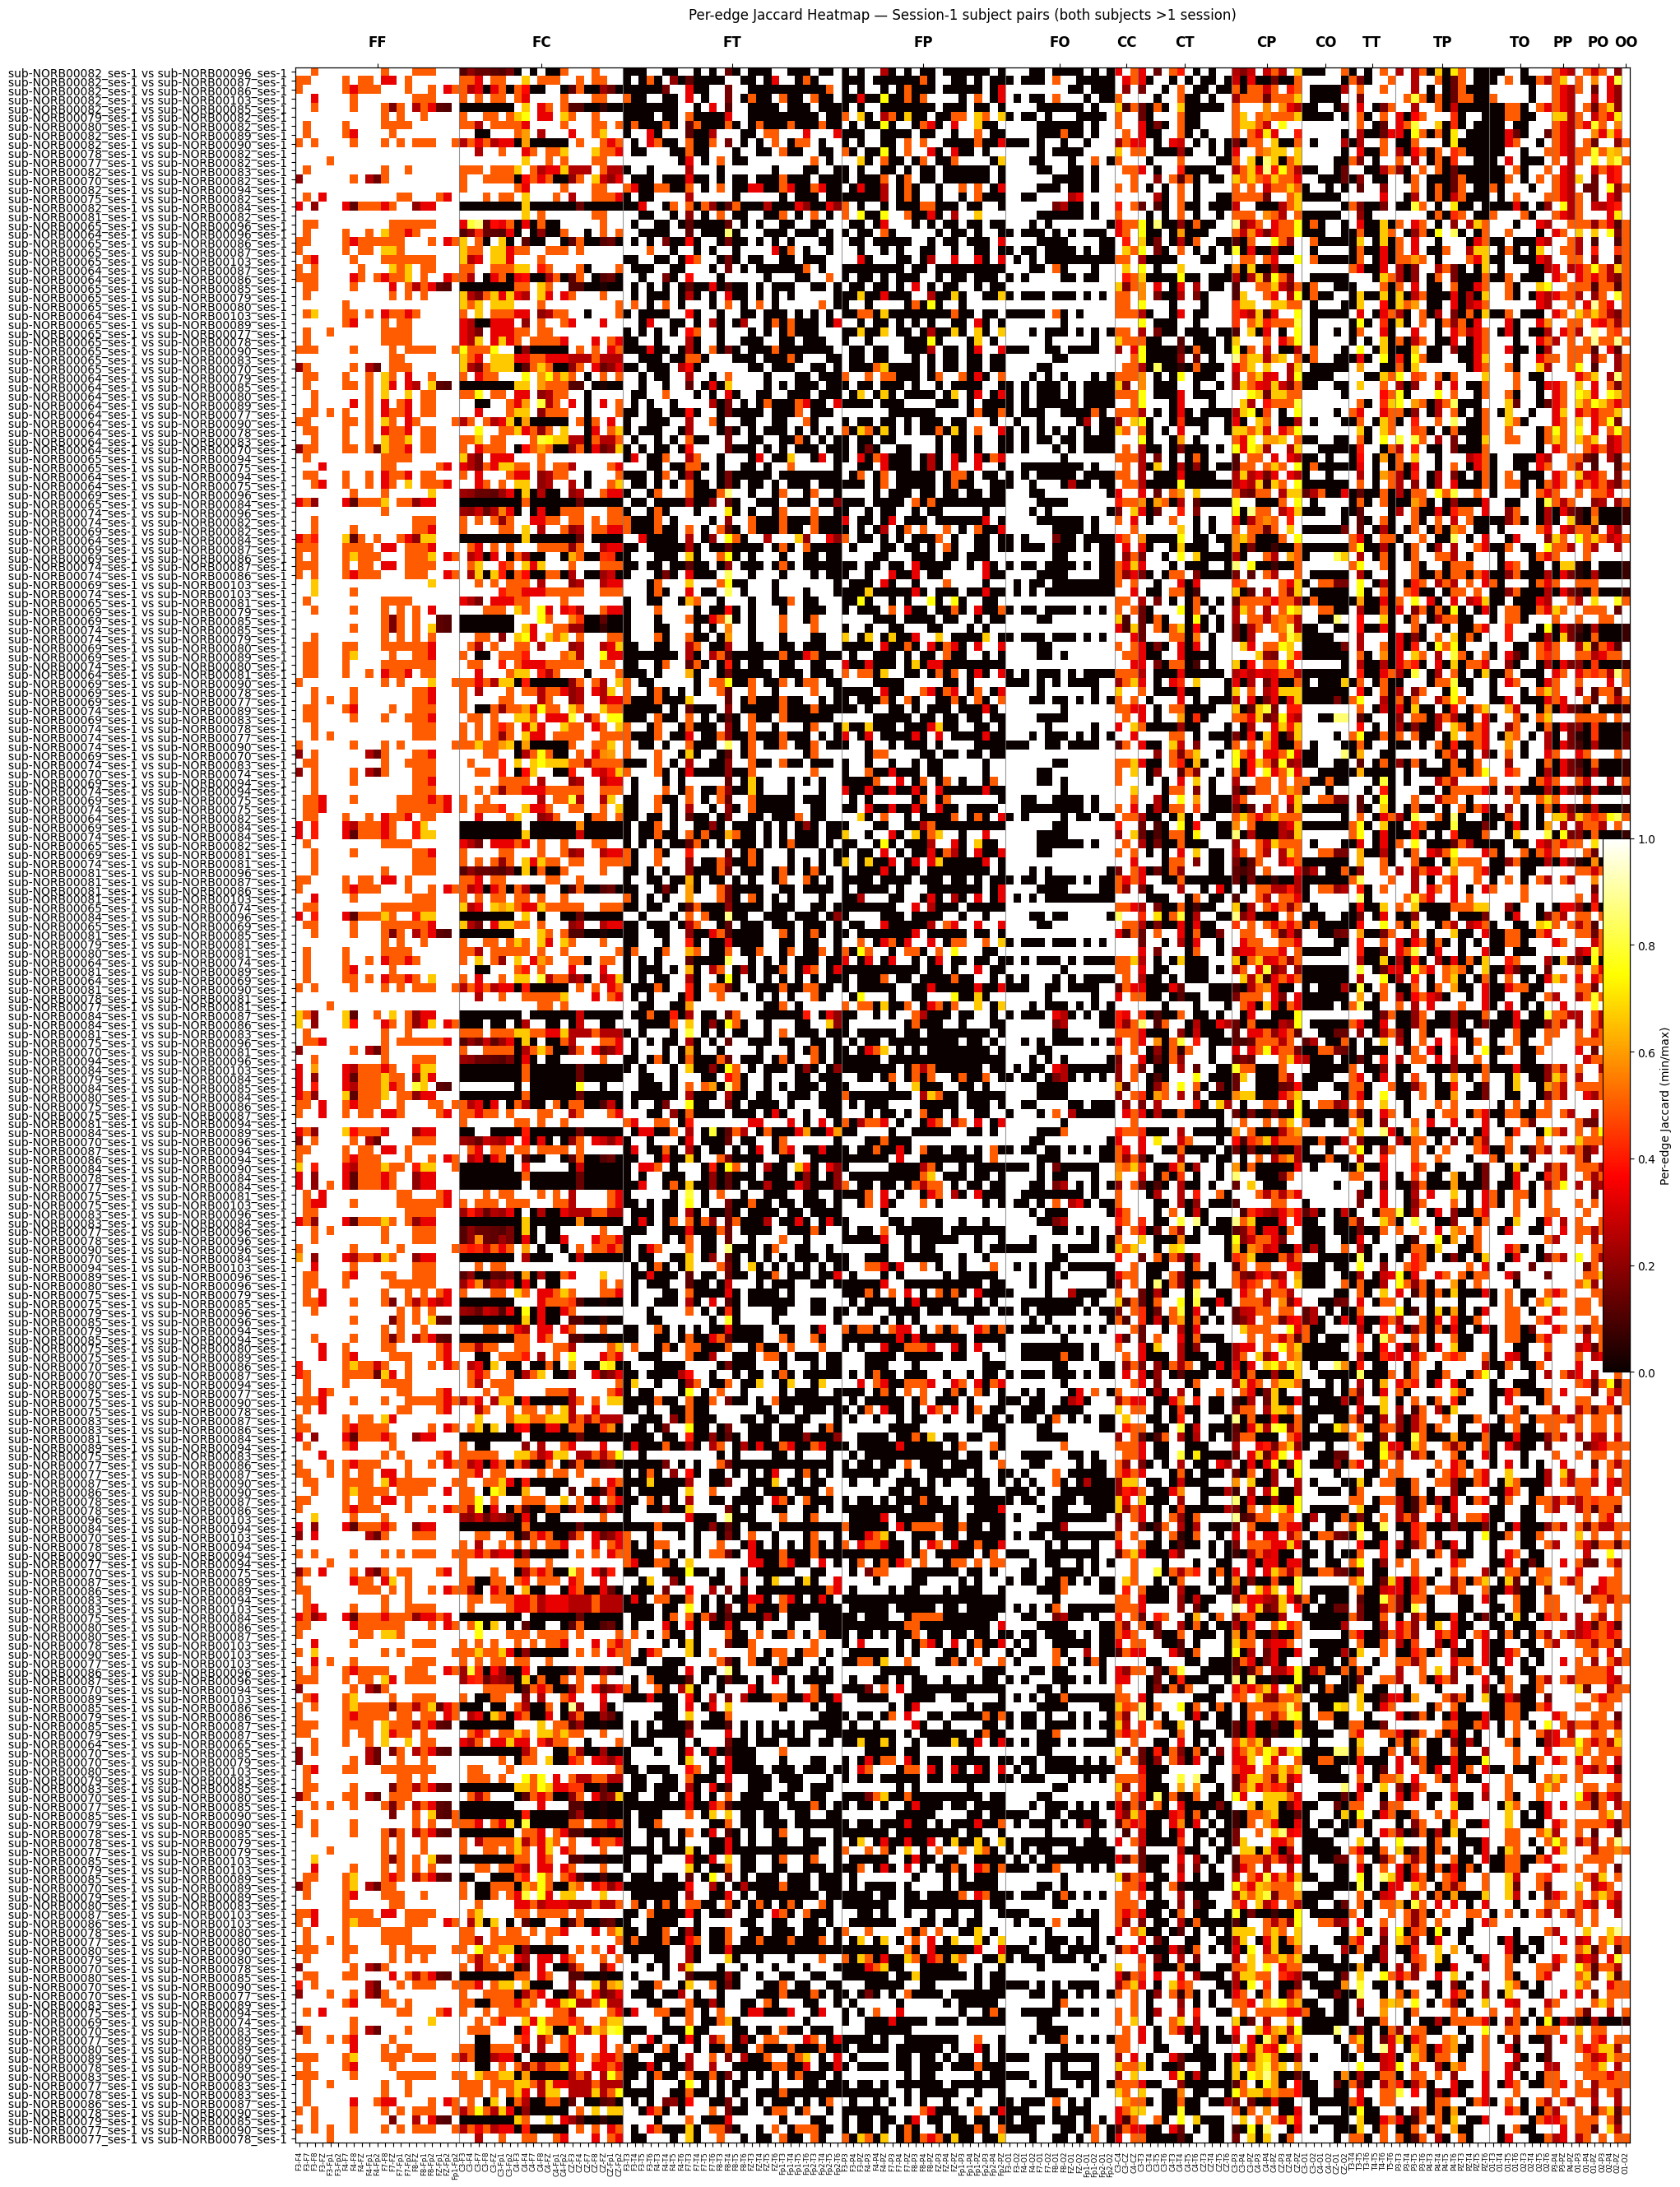

Saved heatmap to jaccard_session1_multi_session_pairs_heatmap.png


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Read ages and find subjects with >1 sessions
age_df = pd.read_csv("age_acq_time_sorted.csv")
age_df["subject"] = age_df["label"].str.split("_ses").str[0]
# subjects with more than one session
multi_subjects = set(age_df["subject"].value_counts()[lambda x: x > 1].index)

# Build mapping label -> age
age_map = dict(zip(age_df["label"], age_df["age_acq_time"]))

# Select candidate subject-session pairs: both session 1 and both subjects have >1 session
pairs_df = pairwise_jaccard_summary_df.copy()
pairs_df["sub_a"] = pairs_df["subject_session_a"].str.split("_ses").str[0]
pairs_df["sub_b"] = pairs_df["subject_session_b"].str.split("_ses").str[0]
mask = (
    pairs_df["subject_session_a"].str.endswith("_ses-1")
    & pairs_df["subject_session_b"].str.endswith("_ses-1")
    & pairs_df["sub_a"].isin(multi_subjects)
    & pairs_df["sub_b"].isin(multi_subjects)
    & (pairs_df["sub_a"] != pairs_df["sub_b"])  # exclude same-subject pairs across sessions
)
selected_pairs = pairs_df[mask].copy()

# Attach ages and compute absolute age difference; drop pairs missing age
selected_pairs["age_a"] = selected_pairs["subject_session_a"].map(age_map)
selected_pairs["age_b"] = selected_pairs["subject_session_b"].map(age_map)
selected_pairs = selected_pairs.dropna(subset=["age_a", "age_b"]).copy()
selected_pairs["age_diff"] = (selected_pairs["age_a"] - selected_pairs["age_b"]).abs()

if selected_pairs.empty:
    print("No session-1 pairs found where both subjects have >1 session and age available.")
else:
    # Determine canonical region for channel names
    def region_code(ch):
        c = str(ch).upper()
        if c.startswith("FP"):
            return "F"
        if c.startswith("F"):
            return "F"
        if c.startswith("C"):
            return "C"
        if c.startswith("T"):
            return "T"
        if c.startswith("P"):
            return "P"
        if c.startswith("O"):
            return "O"
        return c[0]

    # Build desired region-pair ordering
    region_order = ["F", "C", "T", "P", "O"]
    group_order = [a + b for a in region_order for b in region_order if region_order.index(a) <= region_order.index(b)]

    # Collect all edges and canonicalize their region-group
    unique_edges = sorted({(r[0], r[1]) for r in pairwise_jaccard_df[["edge_u", "edge_v"]].itertuples(index=False)}, key=lambda x: (str(x[0]), str(x[1])))

    def canonical_group(edge):
        a, b = edge
        ra, rb = region_code(a), region_code(b)
        if region_order.index(ra) <= region_order.index(rb):
            return ra + rb
        else:
            return rb + ra

    # Order edges by requested groups and then by node names within each group
    edges_by_group = {}
    for e in unique_edges:
        grp = canonical_group(e)
        edges_by_group.setdefault(grp, []).append(e)
    ordered_edges = []
    for grp in group_order:
        if grp in edges_by_group:
            ordered_edges.extend(sorted(edges_by_group[grp], key=lambda x: (str(x[0]), str(x[1]))))

    # Prepare pivot table of per-edge Jaccard values
    pj = pairwise_jaccard_df.copy()
    pj["pair_key"] = pj["subject_session_a"] + "||" + pj["subject_session_b"]

    selected_pairs = selected_pairs.sort_values("age_diff", ascending=True)
    ordered_pair_keys = (selected_pairs["subject_session_a"] + "||" + selected_pairs["subject_session_b"]).tolist()

    # Print counts for debugging / user
    print(f"Selected subject-session pairs used in heatmap: {len(ordered_pair_keys)}")

    pivot = (
        pj[pj["pair_key"].isin(ordered_pair_keys)]
        .pivot(index="pair_key", columns=["edge_u", "edge_v"], values="jaccard_index")
    )

    # Ensure all ordered_edges present as columns
    pivot = pivot.reindex(columns=ordered_edges, fill_value=0.0)

    # Build matrix and labels. We want least age diff at bottommost row -> reverse rows when plotting
    matrix = pivot.loc[ordered_pair_keys].to_numpy(dtype=float)
    matrix_plot = matrix[::-1, :]

    # X labels as 'u-v'
    xlabels = [f"{u}-{v}" for (u, v) in ordered_edges]
    # Y labels as 'subA vs subB (Δ=...)', order reversed for plotting
    pair_labels = [k.replace("||", " vs ") for k in ordered_pair_keys]
    ylabels = pair_labels[::-1]

    # Plot using imshow to enable dual x-axis control
    fig, ax = plt.subplots(figsize=(max(18, len(ordered_edges) * 0.12), max(4, matrix_plot.shape[0] * 0.12)))
    im = ax.imshow(matrix_plot, aspect='auto', cmap='hot', vmin=0.0, vmax=1.0)

    # Bottom axis: per-edge labels on the main axis
    ax.set_xticks(np.arange(len(ordered_edges)))
    ax.set_xticklabels(xlabels, rotation=90, fontsize=6)
    ax.xaxis.set_ticks_position('bottom')
    ax.xaxis.set_label_position('bottom')

    # Top axis: cluster group labels using a separate twin axis
    ax_top = ax.twiny()
    ax_top.set_xlim(ax.get_xlim())

    group_centers = []
    visible_groups = []
    curr = 0
    group_boundaries = []
    for grp in group_order:
        count = len(edges_by_group.get(grp, []))
        if count > 0:
            start = curr
            end = curr + count
            center = (start + end - 1) / 2.0
            group_centers.append(center)
            visible_groups.append(grp)
            curr = end
            group_boundaries.append(end)

    ax_top.set_xticks(group_centers)
    ax_top.set_xticklabels(visible_groups, fontsize=12, fontweight='bold')
    ax_top.xaxis.set_ticks_position('top')
    ax_top.xaxis.set_label_position('top')
    ax_top.tick_params(axis='x', pad=12)

    # Draw vertical separators between groups for clarity (at boundary-0.5)
    for b in group_boundaries[:-1]:
        ax.axvline(x=b - 0.5, color='gray', linewidth=0.8, alpha=0.8)

    # Y labels
    ax.set_yticks(np.arange(matrix_plot.shape[0]))
    ax.set_yticklabels(ylabels)
    ax.yaxis.set_ticks_position('left')

    # Colorbar
    cbar = fig.colorbar(im, ax=ax, orientation='vertical', fraction=0.02, pad=0.02)
    cbar.set_label('Per-edge Jaccard (min/max)')

    plt.title("Per-edge Jaccard Heatmap — Session-1 subject pairs (both subjects >1 session)", y=1.02)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    outpath = "jaccard_session1_multi_session_pairs_heatmap.png"
    fig.savefig(outpath, dpi=200)
    plt.show()
    print(f"Saved heatmap to {outpath}")